# Core Concept

# What is Terraform ?
--> Teraaform is a Infrastructure as a code tool that allows us to automate infrastructure and system.

Terraform is an open-source Infrastructure as Code (IaC) tool developed by HashiCorp that allows us to create, modify, and manage infrastructure using code.

Instead of manually creating AWS resources:
AWS Console
↓
Create VPC
Create EC2
Create Security Group

We write code:
resource "aws_instance" "web" {
  instance_type = "t2.micro"
}

Why Terraform?
Benefits

✅ Automation

✅ Infrastructure as Code

✅ Version Control

✅ Consistency

✅ Repeatability

✅ Multi-cloud Support

# Comparsions with other tools

1. Terraform vs Ansible :
Terraform is primarily used for infrastructure provisioning, while Ansible is used for configuration management and application deployment. Typically, Terraform creates infrastructure such as EC2 instances, and Ansible configures those instances.

2. Terraform vs CloudFormation :
Terraform is a multi-cloud Infrastructure as Code tool, whereas CloudFormation is AWS's native Infrastructure as Code service. Terraform can provision resources across multiple cloud providers, while CloudFormation is limited to AWS resources.


# Setup AWS instance and install terraform on server and local 

1. Create instance in AWS and do the ssh in local to work on ubuntu server.
2. Open ubuntu server and there install the terraform from hashicorp terraform google.
3. Install in local and work with vs code.


# Hashicorp Configuration Language (HCL) in depth
HCL (HashiCorp Configuration Language) is the language used by Terraform to define infrastructure in a human-readable way.

Basic syntax : 
<block_type> <resource_type> <resource_name> {

  argument = value

}

Example : 
  resource "aws_instance" "web" {
  ami           = "ami-123456"
  instance_type = "t2.micro"
}


# Types of blocks :
1. Provider Block : Used to connect Terraform with cloud platforms.
Example :
  provider "aws" {
  region = "us-east-1"
}
purpose :
Terraform → AWS API
Terraform → Azure API
Terraform → GCP API

2. Resource Block : Creates infrastructure.
resource "aws_instance" "web" {
  ami           = "ami-12345"
  instance_type = "t2.micro"
}
Examples: EC2, S3, VPC, Security Group, IAM

3. Variable Block : Makes code reusable.
variable "instance_type" {
  default = "t2.micro"
}
Usage : instance_type = var.instance_type

4. Output Block : Displays useful information.
Example :output "public_ip" {
  value = aws_instance.web.public_ip
}

5. Module Block : Reuses existing Terraform code.
Example : module "vpc" {
  source = "terraform-aws-modules/vpc/aws"
}


# Expressions & Functions

1. Expressions : Expressions allow dynamic values.

2. String Interpolation : Used to combine strings and variables.
Example:
tags = {
  Name = "${var.env}-ec2-instance"
}
output : dev-ec2-instance

3. Terraform Functions : Functions perform operations.
Syntax : function_name(argument)

file() : Reads content from a file.
Example : public_key = file("terra-key.pub")

length() : length(["a","b","c"])

upper() : upper("gunjan")

lower() : lower("AWS")

trim() : trim(" hello ")

lookup() : lookup(var.instance_type,"dev","t2.micro")

join() : join("-",["dev","web","server"])

4. Meta Arguments : Meta arguments control Terraform resource behavior.

depends_on : The depends_on meta argument explicitly declares resource dependencies, ensuring Terraform creates resources in the required order when dependencies cannot be inferred automatically.

Example: resource "aws_instance" "web" {
depends_on = [
    aws_security_group.sg
  ]
}

count : Creates multiple copies.
Example:
resource "aws_instance" "web" {
count = 3
ami           = "ami-123"
instance_type = "t2.micro"
}

for_each : Creates multiple resources with names.
Example:
resource "aws_instance" "web" {

  for_each = {
    instance1 = "web1"
    instance2 = "web2"
  }

}

5. Conditional Expressions : Conditional expressions allow Terraform to choose values dynamically based on a condition.
   
Terraform's IF-ELSE.

Syntax: condition ? true_value : false_value
Example: instance_type = var.env == "prd" ? "t3.large" : "t2.micro"



# Terraform workflow
The Terraform workflow follows:

Write
  ↓
Init
  ↓
Validate
  ↓
Plan
  ↓
Apply
  ↓
Manage
  ↓
Destroy

Step 1: Write Terraform Code

Create a file: main.tf
Examples: 
resource "local_file" "my_file" {
  filename = "automate.txt"
  content  = "Learning terraform"
}

Step 2: Terraform Init

Command: terraform init

Purpose:
Initializes Terraform working directory
Downloads providers
Creates .terraform directory
Creates .terraform.lock.hcl

Run: terraform init

only: 
✓ First time
✓ When provider version changes
✓ When module changes

.terraform Directory :

Contains:
Downloaded Providers
Modules
Metadata

Example:
.terraform/
 ├── providers/
 └── modules/

.terraform.lock.hcl

Purpose: Locks provider versions

Example: AWS Provider 5.83.0

Step 3: Terraform Validate

Command: terraform validate

Purpose: 
Checks syntax
Checks configuration

Example: Success! The configuration is valid.

Detects: 
Missing bracket
Invalid resource type
Wrong syntax

Step 4: Terraform Plan

Command: terraform plan

Purpose: 
Preview changes
Nothing is actually created

Plan  is Basically  "What Terraform will do" before actually doing it.

Step 5: Terraform Apply

Command: terraform apply

Purpose: Creates actual infrastructure

Auto Approve: terraform apply -auto-approve

Step 6: Terraform State

After apply: ls
Output: 
main.tf
terraform.tfstate

terraform.tfstate
Stores: 
What Terraform has created
Current infrastructure state
Resource IDs
Metadata

Step 7: Terraform Destroy

Command: terraform destroy

Purpose: Deletes infrastructure

Auto Approve Destroy: terraform destroy -auto-approve

# Terraform Providers
What is a Provider?
A provider is a plugin that enables Terraform to interact with APIs.

Examples: 
AWS
Azure
GCP
Kubernetes
GitHub
Docker

Provider Example:
provider "aws" {
  region = "us-east-1"
}

Terraform uses this provider to:
Create EC2
Create S3
Create VPC
Create IAM

Check Providers

Command: terraform providers

Output:
Providers required by configuration:
.
└── provider[registry.terraform.io/hashicorp/aws]

Provider Installation Flow:
provider "aws"
       ↓
terraform init
       ↓
Downloads AWS Provider
       ↓
Stored in .terraform

AWS Provider Deep Dive :

AWS Provider Most commonly used Terraform provider.

Example: 
provider "aws" {
  region = "us-east-1"
}

Authentication Methods

Terraform can authenticate using:

1. AWS CLI : aws configure

2. Environment Variables :
export AWS_ACCESS_KEY_ID=xxxxx
export AWS_SECRET_ACCESS_KEY=xxxxx

3. IAM Roles Best practice.
Example:
Terraform Running on EC2
↓
Uses IAM Role
↓
Temporary Credentials

4. Shared Credentials File

Location:
Windows: C:\Users\<user>\.aws\credentials

Interview Questions
1. What does terraform init do?
Answer:
Initializes the working directory, downloads providers and modules, and creates the .terraform directory and lock file.

2. Difference between plan and apply?
terraform plan : Preview Changes -> No resources created.

terraform apply: Actually Creates Resources

3. What is terraform validate?
Answer: It validates Terraform configuration files and checks syntax without creating infrastructure.

4. What is terraform.tfstate?
Answer: Terraform state file maintains a mapping between Terraform configuration and actual infrastructure resources.

5. What is a Provider?
Answer:A provider is a plugin that allows Terraform to interact with a specific platform such as AWS, Azure, GCP, Kubernetes, or GitHub.

6. What is AWS Provider?
Answer:AWS Provider enables Terraform to communicate with AWS APIs and manage AWS resources such as EC2, S3, VPCs, IAM roles, Security Groups, and EKS clusters.

7. What is terraform refresh ?
Purpose : Updates Terraform state with current infrastructure.

8. What is terraform fmt ?
Purpose : Formats Terraform files according to HashiCorp standards.

# Terraform CLI & Command
- Core Command : init, plan,apply,destroy,refresh, validate,fmt
- Advanced command : taint,import,graph,state manipulation
- Debugging terraform issues


Terraform CLI (Command Line Interface) is used to interact with Terraform and manage infrastructure through commands.

Terraform Commands
        │
        ├── Core Commands
        │      ├── init
        │      ├── validate
        │      ├── fmt
        │      ├── plan
        │      ├── apply
        │      ├── refresh
        │      └── destroy
        │
        ├── Advanced Commands
        │      ├── taint
        │      ├── import
        │      ├── graph
        │      └── state
        │
        └── Debugging Commands

Advanced Commands: 

1. terraform taint
Purpose : Marks a resource for recreation.

Command: terraform taint aws_instance.web

Output: Resource marked as tainted.

terraform apply: Terraform destroys and recreates the resource.

Example :
EC2 Corrupted
↓
terraform taint EC2
↓
terraform apply
↓
New EC2

Remove Taint : terraform untaint aws_instance.web

2. terraform import
Purpose : Imports existing infrastructure into Terraform state.

Command: terraform import aws_s3_bucket.bucket my-prod-bucket

3. terraform graph
Purpose : Shows resource dependency graph.

Command : terraform graph

Output:
VPC
 ↓
Security Group
 ↓
EC2

4. State Manipulation Commands

Terraform State is critical.

View State : terraform state list

Output:
aws_instance.web
aws_security_group.sg
aws_vpc.main

Show Resource Details : terraform state show aws_instance.web

Displays:
ID
AMI
Instance Type
Public IP
Private IP


Remove from State : terraform state rm aws_instance.web

Removes resource from state only.
Does NOT delete actual AWS resource.

Move State Resource : terraform state mv old_name new_name

# Common Real-World Errors
Error 1 : Provider version conflict
Solution: terraform providers
Check module/provider compatibility.

Error 2 : InvalidAMIID.NotFound
Solution: Wrong or deleted AMI


Error 3 : AccessDenied
Solution: aws sts get-caller-identity
Verify IAM permissions.

Error 4 : Unsupported argument
Solution: terraform validate
Check module and provider versions.

# Terraform variables & Expression

Variables and Expressions make Terraform configurations dynamic, reusable, and environment-independent.

Instead of hardcoding values: instance_type = "t2.micro"

we use: instance_type = var.instance_type

This allows the same code to be used in: 
Dev
QA
UAT
Production

1. Types of Variables

Terraform supports three major types of variables:

Variables
   │
   ├── Input Variables
   ├── Output Variables
   └── Local Variables

1. Input Variables

Input Variables accept values from users.

Syntax :
variable "instance_type" {
  type    = string
  default = "t2.micro"
}

Usage: 
resource "aws_instance" "web" {
  instance_type = var.instance_type
}

2. Output Variables : Output variables display values after deployment.

Example :
output "public_ip" {
  value = aws_instance.web.public_ip
}

Output: 54.123.45.67

View Outputs: terraform output

3. Local Variables : Local variables reduce repetition.

Without locals:
tags = {
  Environment = "dev"
}
bucket = "dev-s3"
name = "dev-ec2"

Advantages of Locals

✅ Reusable

✅ Cleaner code

✅ Easier maintenance

✅ Reduced duplication

Expressions : Expressions calculate values dynamically.

Example: instance_type = var.instance_type

Terraform evaluates the expression and assigns the value.


2. Dynamic Configuration :Dynamic configuration allows infrastructure to change based on conditions, loops, and environment values.

Conditional Expressions "Terraform's IF-ELSE.

Syntax : condition ? true_value : false_value

Example : instance_type = var.env == "prd" ? "t3.large" : "t2.micro"

Count : Creates multiple identical resources.

Example :
resource "aws_instance" "web" {
  count = 3
  ami           = "ami-123"
  instance_type = "t2.micro"
}

for_each : Creates multiple resources with unique names.

Example : 
resource "aws_instance" "web" {

  for_each = {

    dev  = "t2.micro"
    qa   = "t2.small"
    prod = "t3.large"
  }

  instance_type = each.value
}

CIDR Block Basics : CIDR = Classless Inter-Domain Routing

CIDR defines IP address ranges.
https://cidr.xyz/

# Terraform state management and Backends

- Role of state in infrastructure managemnet : done
- Secure state management best practices : terraform.tf.state file will hold all info. (this file we can't commit to github) (created remote-infra) to get the backup file of tf.state file through backend s3. 
- Remote State Backends
   - AWS S3 for remote storage
   - State locking with dynamoDB

(how to create remote backend on s3 and link it through dynamo table and we can safely left go our local tf state)

Terraform State is a file that keeps track of all infrastructure created by Terraform.

File Name: terraform.tfstate

When Terraform creates a resource, it stores information in this file.

Terraform stores:
EC2 Instance ID
Public IP
Private IP
Resource ARN
Dependencies
Metadata

Problem with Local State

By default: terraform.tfstate is stored locally.

Example:
Laptop
 ├── main.tf
 └── terraform.tfstate

Problems: Single Point of Failure
If laptop crashes: State File Lost

Team Collaboration Issues

Developer 1 : terraform.tfstate
Developer 2 : terraform.tfstate

Different states create conflicts.

Security Risk

State file may contain:
Passwords
Database Endpoints
IAM Information
Private IPs
Access Keys

Therefore:

✅ Never commit state files to GitHub

Git Ignore
terraform.tfstate
terraform.tfstate.backup
.terraform/


Secure State Management Best Practices
Never Push State File to GitHub

Wrong:
GitHub
 └── terraform.tfstate

Correct:
GitHub
 └── Terraform Code Only

Use Remote Backend

Store state in:
AWS S3
Azure Storage
Terraform Cloud
GCS


Enable State Locking : Prevents multiple users running Terraform simultaneously.

Enable Versioning : Recover previous states.


What is a Backend?

Backend determines where Terraform State is stored.

Default: Local Backend,terraform.tfstate..stored locally.

Types of Backends
1. Local Backend : Laptop
2. Remote Backends : 
S3
Azure Storage Account
Terraform Cloud
GCS


AWS S3 Backend : Most commonly used in AWS projects.

Architecture:
Developer
     ↓
Terraform
     ↓
S3 Bucket
     ↓
terraform.tfstate

Benefits of S3 Backend

✅ Centralized State

✅ Team Collaboration

✅ Secure

✅ Versioning

✅ Backup

✅ Recovery



Interview Questions
1. What is Terraform State?

Answer: Terraform state is a mapping between Terraform configuration and real-world infrastructure resources. It stores resource IDs, metadata, dependencies, and infrastructure information.

2. Why should terraform.tfstate not be committed to GitHub?

Answer: State files may contain sensitive information such as resource IDs, IP addresses, database endpoints, and secrets. Storing them in GitHub creates security risks and state management issues.

3. Why use Remote Backend?

Answer:Remote backends provide centralized, secure, and shared state storage, enabling team collaboration and disaster recovery.

4. Why use S3 Backend?

Answer:S3 offers durable, highly available, versioned storage for Terraform state in AWS environments.

5. Why use DynamoDB with S3?

Answer: DynamoDB provides state locking, preventing multiple users from modifying Terraform state simultaneously and avoiding state corruption.

6. How does State Locking work?
terraform apply
↓
DynamoDB Lock Created
↓
Other Users Blocked
↓
Apply Complete
↓
Lock Released


7. Real Production Workflow

Create Backend Infrastructure
(S3 + DynamoDB)
↓
Configure backend block
↓
terraform init
↓
State Migrated
↓
All Future State Stored in S3
↓
Locking Managed by DynamoDB


# Terraform workspaces & Environment management

What is a Terraform Workspace?
A Terraform Workspace allows you to maintain multiple state files for the same Terraform configuration.
Using workspaces, you can manage:
Development (dev)
Testing (qa)
Staging (stage)
Production (prd/prod)
without duplicating Terraform code.

--> How Workspaces Work
Terraform maintains separate state files.

Example:
default workspace
      ↓
terraform.tfstate

dev workspace
      ↓
separate state

stage workspace
      ↓
separate state

prod workspace
      ↓
separate state

Each workspace manages its own infrastructure.

---> Creating Workspaces

Create a new workspace: terraform workspace new dev
Output: Created and switched to workspace "dev"

Create Stage: terraform workspace new stage

Create Production: terraform workspace new prod

---> List Workspaces

Command: 
terraform workspace list

---> Switch Workspaces

Move to Stage: terraform workspace select stage
Move to Prod: terraform workspace select prod
Check Current Workspace: terraform workspace show

---> Delete Workspace : Cannot delete current workspace.

Switch first: terraform workspace select default

Delete: terraform workspace delete dev

----> Workspaces with Remote Backend

When using S3 Backend:
backend "s3" {
  bucket = "terraform-state-bucket"
  key    = "terraform.tfstate"
  region = "us-east-1"
}

Terraform automatically creates:
For Dev: env:/dev/terraform.tfstate
For Stage: env:/stage/terraform.tfstate
For Prod: env:/prod/terraform.tfstate

Each workspace gets its own state file.

Interview Questions
1. What is a Terraform Workspace?

Answer: A Terraform workspace is a mechanism that allows multiple state files to exist for a single Terraform configuration. It is commonly used to manage environments such as development, staging, and production.

2. Why Use Workspaces?

Answer: Workspaces help manage multiple environments using the same Terraform code while keeping their state files isolated.

3. How Do You Check Current Workspace?
terraform workspace show

4. How Do You Switch Between Environments?
terraform workspace select dev
terraform workspace select prod

5. What is terraform.workspace?
Answer:
terraform.workspace is a built-in Terraform expression that returns the name of the currently selected workspace.

Example:
Terraform
tags = {
Environment = terraform.workspace3
}

# Terraform Modules - Reusability & Best Pratices
A module is a collection of Terraform configuration files that work together to create infrastructure components.

Think of a module as:
Function in Programming
          =
Module in Terraform

Instead of writing the same code multiple times, we create it once and reuse it.

Types of Modules
Terraform Modules
       │
       ├── Root Module
       ├── Child Module
       └── Registry Module

1. Root Module : The Terraform code where execution starts.

Example: 
main.tf
variables.tf
outputs.tf

This directory itself is the Root Module.

2. Child Module : A module called by another module.

Example:
module "ec2" {
  source = "./modules/ec2"

3. Registry Modules :
Pre-built modules available in Terraform Registry.

Website: https://registry.terraform.io

Examples:
VPC Module
EKS Module
Security Group Module
RDS Module
IAM Module


--> Popular Terraform Registry Modules

VPC : source = "terraform-aws-modules/vpc/aws"

EKS : source = "terraform-aws-modules/eks/aws"

Security Group : source = "terraform-aws-modules/security-group/aws"

IAM : source = "terraform-aws-modules/iam/aws"

---> Creating Custom Modules

Suppose you frequently create EC2 instances.
Instead of rewriting EC2 code, create a custom module.

Module Structure :
Recommended Structure :
terraform-project/
│
├── main.tf
│
└── modules/
    │
    └── ec2/
        │
        ├── main.tf
        ├── variables.tf
        ├── outputs.tf
        └── README.md

Interview Questions
1. What is a Terraform Module?
Answer: A Terraform Module is a reusable container of Terraform resources that helps organize infrastructure code and reduce duplication.

2. Difference Between Root Module and Child Module?

Root Module : Where Terraform execution starts.
Child Module : A reusable module called by another module.

3. What is Terraform Registry?
Answer: Terraform Registry is a repository of pre-built Terraform modules and providers that can be reused to deploy infrastructure quickly.

4. Why Use Modules?
Answer:Modules improve reusability, maintainability, scalability, and standardization of infrastructure code.

5. How Do Modules Pass Data?
Using Input Variables
Outputs


# Terraform-EKS

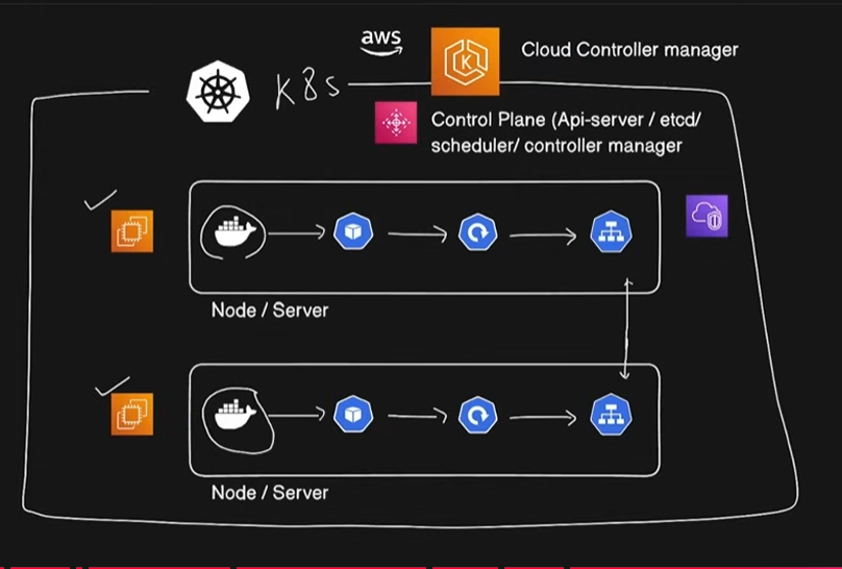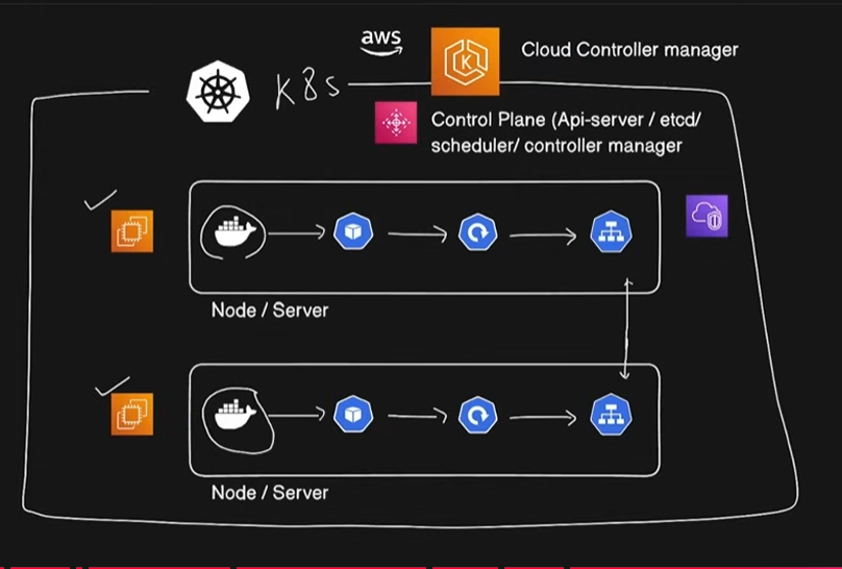

Will implement terraform from above image.

